# NORMALISASI ROBUST #

In [51]:
import pandas as pd
from sklearn.preprocessing import RobustScaler

# ==============================================================================
# DATA
# ==============================================================================
df_robust = pd.read_csv('dataset_fasilitas_kesehatan_skripsi_kedua.csv')
kolom_string = [
    'kode_provinsi',
    'kode_kabupaten_kota',
]

df_robust[kolom_string] = df_robust[kolom_string].astype(str)

kolom_numerik = [
    col for col in df_robust.select_dtypes(include='number').columns
    if col != 'tahun'
]

print("=========== DATA ===========")
df_robust

=========== DATA ===========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,9,15,347,141,619,41173,292,592938
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,12,19,519,129,990,46778,479,962125
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,3,19,384,227,792,40464,285,748432
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,14,18,609,263,1098,114929,507,1109547
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,6,18,540,233,837,65232,392,1230159
...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,8,0,1,0,261,18844,287,213469
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,6,0,4,0,396,16010,129,142272
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,6,0,5,0,521,23764,756,201733
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,40,23,69,0,7446,851331,2299,3018022


In [52]:
# ==============================================================================
# STANDARDISASI ROBUST
# ==============================================================================
scaler = RobustScaler()

df_robust[kolom_numerik] = scaler.fit_transform(df_robust[kolom_numerik])

print("========== HASIL STANDARDISASI ROBUST ==========")
df_robust

========== HASIL STANDARDISASI ROBUST ==========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,0.230769,-0.153846,-0.484434,0.046307,-0.534189,-0.290467,-0.355131,-0.763722
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,0.461538,0.153846,-0.223235,-0.006615,-0.120011,-0.258875,-0.281465,-0.194139
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,-0.230769,0.153846,-0.428246,0.425579,-0.341055,-0.294463,-0.357889,-0.523826
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,0.615385,0.076923,-0.086560,0.584344,0.000558,0.125248,-0.270435,0.033304
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,0.000000,0.076923,-0.191344,0.452040,-0.290818,-0.154862,-0.315738,0.219384
...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,0.153846,-1.307692,-1.009871,-0.575524,-0.933854,-0.416321,-0.357101,-1.349168
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,0.000000,-1.307692,-1.005315,-0.575524,-0.783143,-0.432294,-0.419342,-1.459011
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,0.000000,-1.307692,-1.003797,-0.575524,-0.643595,-0.388590,-0.172346,-1.367275
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,2.615385,0.461538,-0.906606,-0.575524,7.087357,4.275868,0.435493,2.977705


* AGGLOMERATIVE HIERARCHICAL CLUSTERING


In [53]:
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import (silhouette_score, davies_bouldin_score, calinski_harabasz_score)

In [54]:
#===============================================================================
# DATA
#===============================================================================

df_robust_ahc = df_robust.copy()
df_robust_ahc

,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,0.230769,-0.153846,-0.484434,0.046307,-0.534189,-0.290467,-0.355131,-0.763722
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,0.461538,0.153846,-0.223235,-0.006615,-0.120011,-0.258875,-0.281465,-0.194139
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,-0.230769,0.153846,-0.428246,0.425579,-0.341055,-0.294463,-0.357889,-0.523826
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,0.615385,0.076923,-0.086560,0.584344,0.000558,0.125248,-0.270435,0.033304
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,0.000000,0.076923,-0.191344,0.452040,-0.290818,-0.154862,-0.315738,0.219384
...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,0.153846,-1.307692,-1.009871,-0.575524,-0.933854,-0.416321,-0.357101,-1.349168
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,0.000000,-1.307692,-1.005315,-0.575524,-0.783143,-0.432294,-0.419342,-1.459011
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,0.000000,-1.307692,-1.003797,-0.575524,-0.643595,-0.388590,-0.172346,-1.367275
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,2.615385,0.461538,-0.906606,-0.575524,7.087357,4.275868,0.435493,2.977705


In [55]:
#===============================================================================
# 1. HITUNG MATRIKS JARAK/LINKAGE
#===============================================================================

linkage_matrix = linkage(
    df_robust_ahc[kolom_numerik],
    method="ward",
    metric="euclidean"
)

print("========== HASIL LINKAGE MATRIX ==========")
linkage_matrix

========== HASIL LINKAGE MATRIX ==========


array([[5.60000000e+01, 9.40000000e+01, 1.07560646e-01, 2.00000000e+00],
       [3.70000000e+01, 7.50000000e+01, 1.19972830e-01, 2.00000000e+00],
       [1.08000000e+02, 1.84000000e+02, 1.38538453e-01, 2.00000000e+00],
       ...,
       [5.22000000e+02, 5.27000000e+02, 2.38930874e+01, 2.55000000e+02],
       [5.26000000e+02, 5.28000000e+02, 3.33837467e+01, 2.64000000e+02],
       [5.24000000e+02, 5.29000000e+02, 6.67600048e+01, 2.66000000e+02]])

In [56]:
#===============================================================================
# 2. PASANGAN CLUSTER TERDEKAT
#===============================================================================

linkage_df = pd.DataFrame(
    linkage_matrix,
    columns=[
        "Cluster 1",
        "Cluster 2",
        "Jarak",
        "Jumlah Anggota"
    ]
)

print("========== PASANGAN CLUSTER TERDEKAT ==========")
linkage_df

========== PASANGAN CLUSTER TERDEKAT ==========


,Cluster 1,Cluster 2,Jarak,Jumlah Anggota
0,56.0,94.0,0.107561,2.0
1,37.0,75.0,0.119973,2.0
2,108.0,184.0,0.138538,2.0
3,33.0,71.0,0.140455,2.0
4,73.0,111.0,0.148753,2.0
...,...,...,...,...
260,516.0,521.0,19.094709,9.0
261,502.0,525.0,20.533084,221.0
262,522.0,527.0,23.893087,255.0
263,526.0,528.0,33.383747,264.0


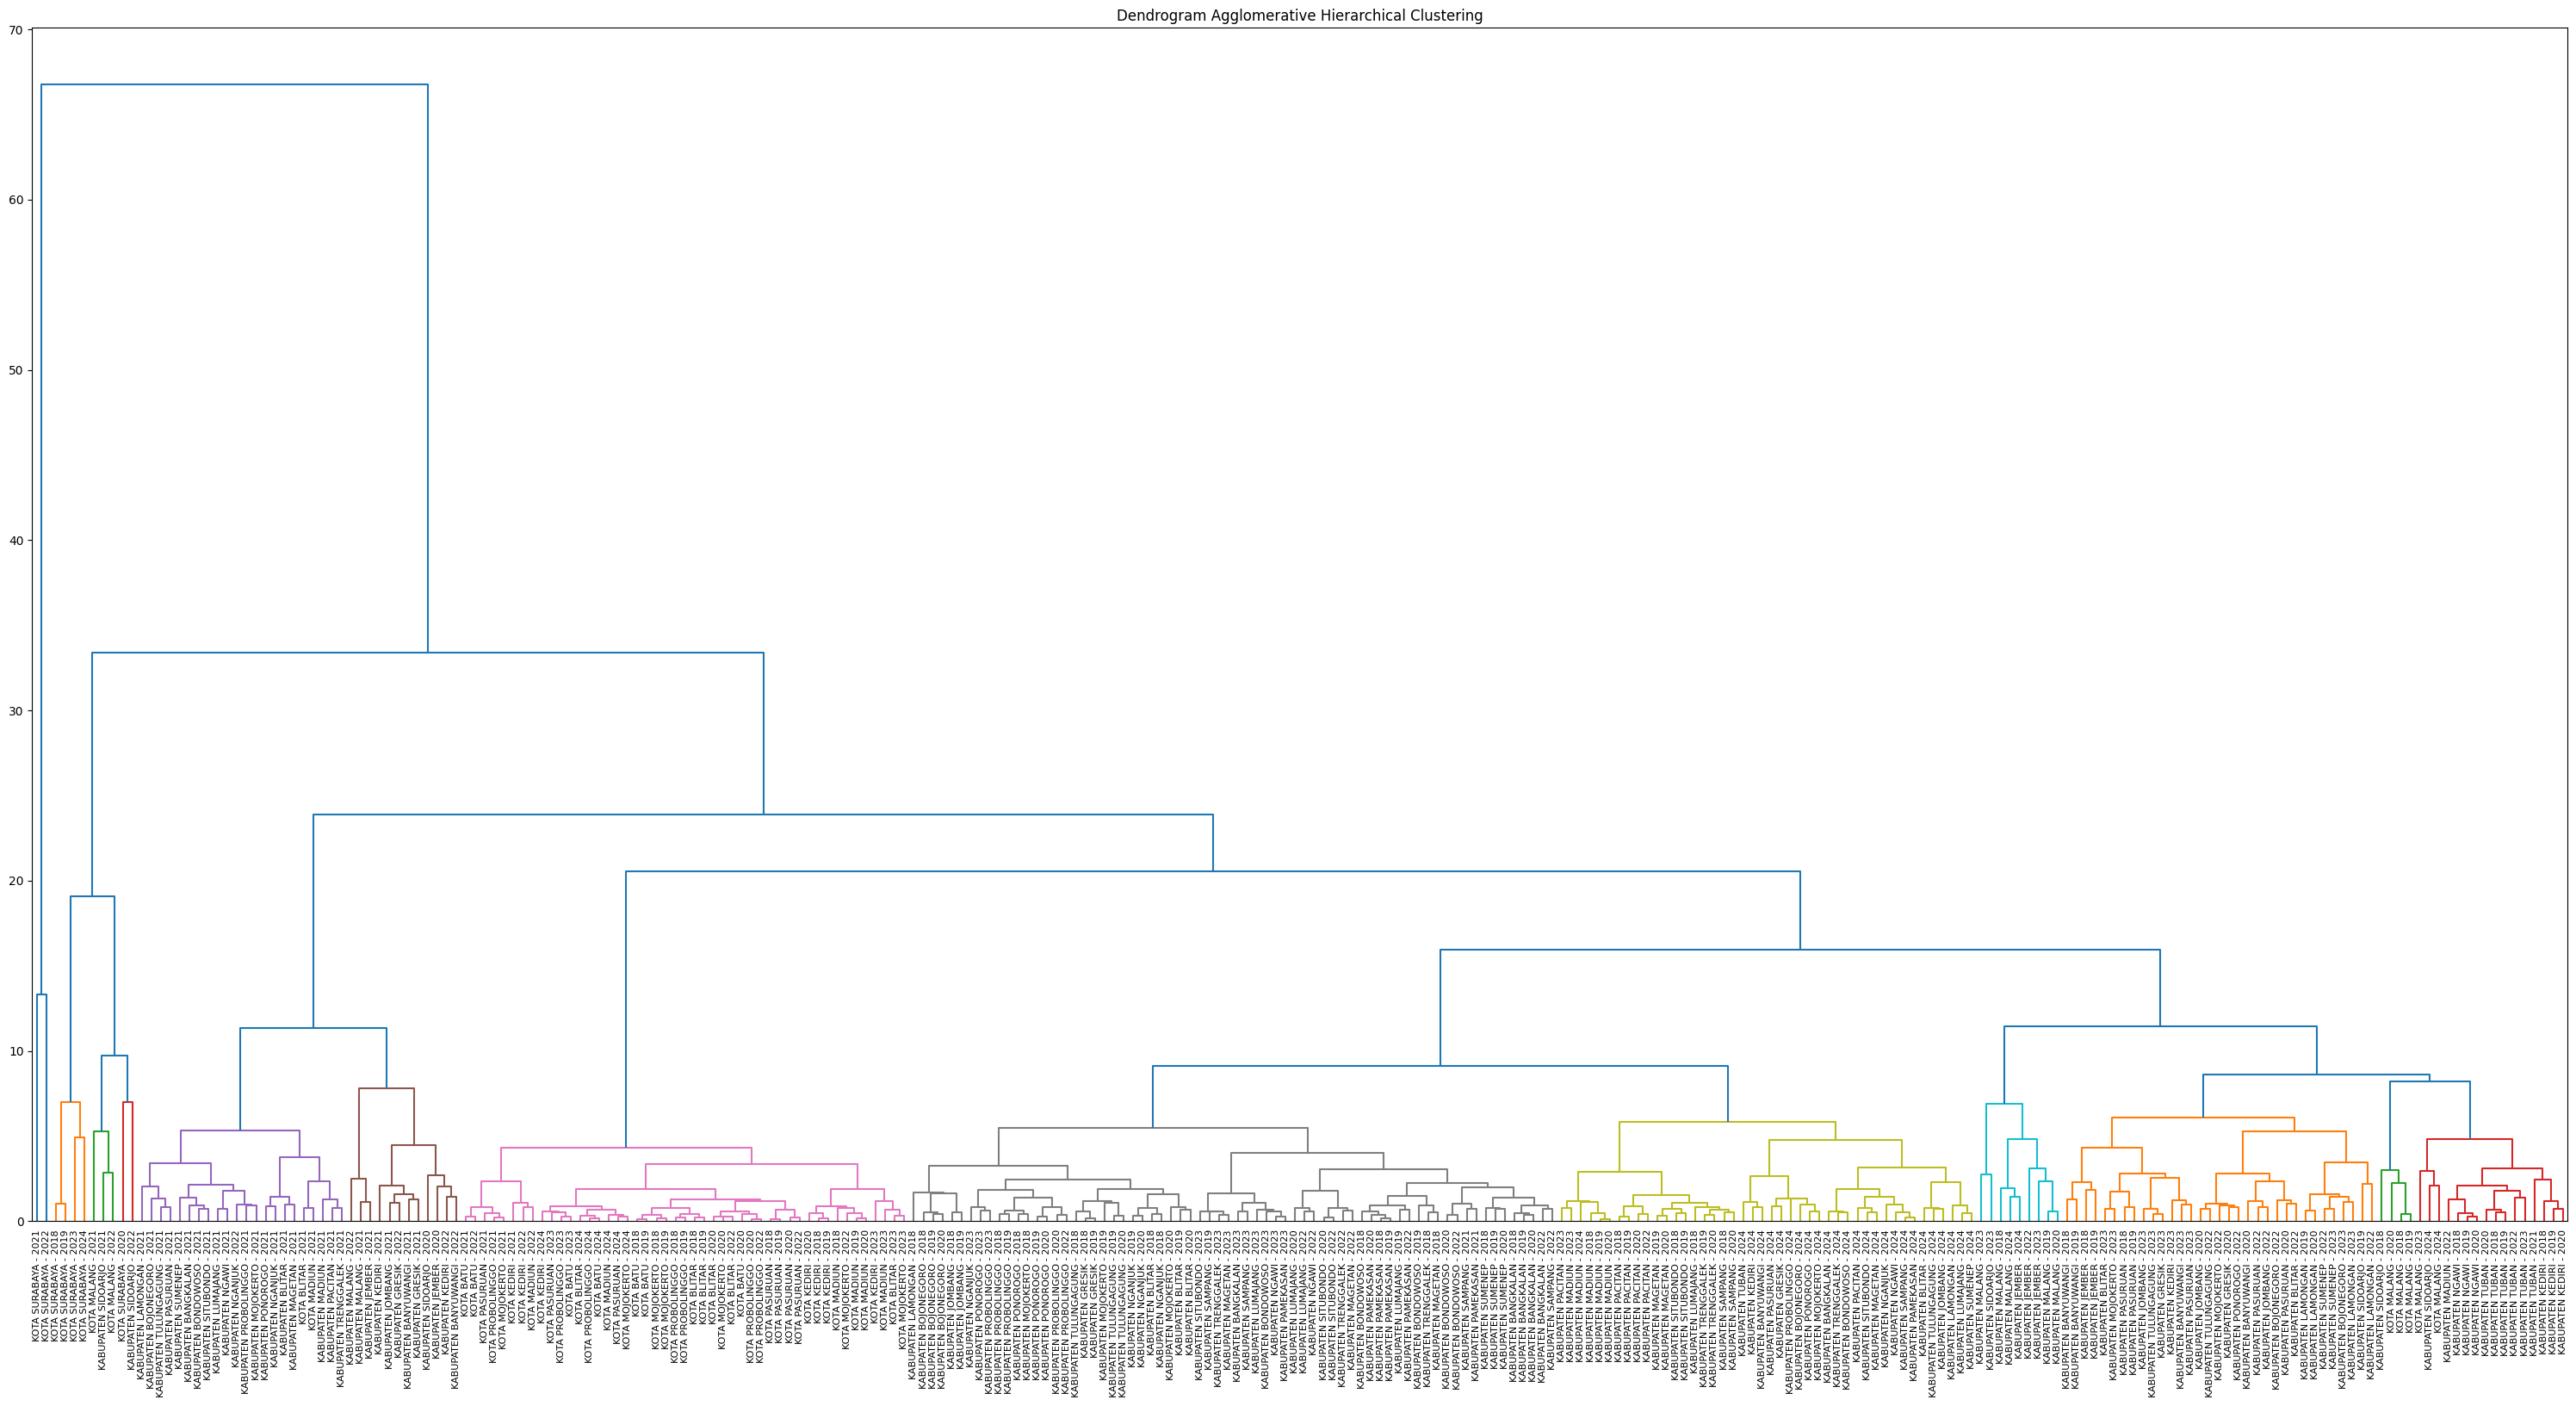

In [57]:
#===============================================================================
# 2.1. DENDROGRAM
#===============================================================================

plt.figure(figsize=(38,18))

dendrogram(
    linkage_matrix,
    color_threshold=8,
    labels = (
    df_robust_ahc["nama_kabupaten_kota"].astype(str)
    + " - "
    + df_robust_ahc["tahun"].astype(str)
).values,
    leaf_rotation=90,
    leaf_font_size=8,
    show_leaf_counts=True,
)

#plt.axhline(y=8, color="r", linestyle="--", linewidth=1)
plt.title("Dendrogram Agglomerative Hierarchical Clustering")

plt.show()

In [58]:
#===============================================================================
# 3. EVALUASI CLUSTER
#===============================================================================

hasil_evaluasi = []

for k in range(2,11):

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward",
        metric="euclidean"
    )

    cluster = model.fit_predict(df_robust_ahc[kolom_numerik])
    
    silhouette = silhouette_score(df_robust_ahc[kolom_numerik], cluster)
    dbi = davies_bouldin_score(df_robust_ahc[kolom_numerik], cluster)
    chi = calinski_harabasz_score(df_robust_ahc[kolom_numerik], cluster)
    
    hasil_evaluasi.append({
    'Jumlah Cluster (K)': k,
    'Silhouette Score': silhouette,
    'Davies-Bouldin Index': dbi,
    'Calinski-Harabasz Index': chi
    })
    
hasil_evaluasi = pd.DataFrame(hasil_evaluasi)
    
print("========== HASIL EVALUASI JUMLAH CLUSTER==========")
display(hasil_evaluasi.round(4))

========== HASIL EVALUASI JUMLAH CLUSTER==========


,Jumlah Cluster (K),Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,2,0.8975,0.2676,262.7124
1,3,0.6851,0.7969,217.7697
2,4,0.3525,1.0080,192.0332
3,5,0.2338,1.0081,180.5782
4,6,0.2419,0.9137,179.4964
5,7,0.2446,1.1465,176.7804
6,8,0.2410,0.9891,172.0510
7,9,0.2485,1.0227,166.4996
8,10,0.2554,1.0469,164.6777


In [59]:
# --------------------------
# 3.1. K OPTIMAL
# --------------------------

print("========== K OPTIMAL ==========")


k_optimal = hasil_evaluasi.loc[hasil_evaluasi['Silhouette Score'].idxmax(), 'Jumlah Cluster (K)']
print("1. K Optimal berdasarkan Silhouette Score:", k_optimal)


========== K OPTIMAL ==========
1. K Optimal berdasarkan Silhouette Score: 2


In [60]:
k_optimal = hasil_evaluasi.loc[hasil_evaluasi['Davies-Bouldin Index'].idxmin(), 'Jumlah Cluster (K)']
print("2. K Optimal berdasarkan Davies-Bouldin Index:", k_optimal)

2. K Optimal berdasarkan Davies-Bouldin Index: 2


In [61]:
k_optimal = hasil_evaluasi.loc[hasil_evaluasi['Calinski-Harabasz Index'].idxmax(), 'Jumlah Cluster (K)']
print("3. K Optimal berdasarkan Calinski-Harabasz Index:", k_optimal)

3. K Optimal berdasarkan Calinski-Harabasz Index: 2


_Pemotongan klaster yang diggunakan_

In [62]:
k = 2

In [63]:
#===============================================================================
# 4. CLUSTERING DENGAN K OPTIMAL
#===============================================================================

ahc = AgglomerativeClustering(
    n_clusters=k,
    linkage="ward",
    metric="euclidean"
)

ahc.fit(df_robust_ahc[kolom_numerik])

AgglomerativeClustering()

In [64]:
#===============================================================================
# 5. SIMPAN LABEL CLUSTER
#===============================================================================

print("========== LABEL CLUSTER ==========")
df_hasil = df_robust_ahc.copy()
df_hasil["cluster_ahc"] = ahc.labels_ + 1
df_hasil

========== LABEL CLUSTER ==========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk,cluster_ahc
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,0.230769,-0.153846,-0.484434,0.046307,-0.534189,-0.290467,-0.355131,-0.763722,1
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,0.461538,0.153846,-0.223235,-0.006615,-0.120011,-0.258875,-0.281465,-0.194139,1
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,-0.230769,0.153846,-0.428246,0.425579,-0.341055,-0.294463,-0.357889,-0.523826,1
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,0.615385,0.076923,-0.086560,0.584344,0.000558,0.125248,-0.270435,0.033304,1
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,0.000000,0.076923,-0.191344,0.452040,-0.290818,-0.154862,-0.315738,0.219384,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,0.153846,-1.307692,-1.009871,-0.575524,-0.933854,-0.416321,-0.357101,-1.349168,1
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,0.000000,-1.307692,-1.005315,-0.575524,-0.783143,-0.432294,-0.419342,-1.459011,1
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,0.000000,-1.307692,-1.003797,-0.575524,-0.643595,-0.388590,-0.172346,-1.367275,1
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,2.615385,0.461538,-0.906606,-0.575524,7.087357,4.275868,0.435493,2.977705,1


In [65]:
#===============================================================================
# 2.5. SIMPAN HASIL CLUSTERING K-MEANS (DATA ASLI)
#===============================================================================
df_hasil = pd.read_csv('dataset_baru.csv').copy()

df_hasil["cluster_ahc"] = ahc.labels_ + 1

print("========== HASIL CLUSTERING AHC ==========")
display(df_hasil)

========== HASIL CLUSTERING AHC ==========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk,cluster_ahc
0,35,JAWA TIMUR,3501,PACITAN,2018,9,15,347,141,619,41173,292,592938,1
1,35,JAWA TIMUR,3502,PONOROGO,2018,12,19,519,129,990,46778,479,962125,1
2,35,JAWA TIMUR,3503,TRENGGALEK,2018,3,19,384,227,792,40464,285,748432,1
3,35,JAWA TIMUR,3504,TULUNGAGUNG,2018,14,18,609,263,1098,114929,507,1109547,1
4,35,JAWA TIMUR,3505,BLITAR,2018,6,18,540,233,837,65232,392,1230159,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,8,0,1,0,261,18844,287,213469,1
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,6,0,4,0,396,16010,129,142272,1
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,6,0,5,0,521,23764,756,201733,1
264,35,JAWA TIMUR,3578,SURABAYA,2024,40,23,69,0,7446,851331,2299,3018022,1


In [66]:
#===============================================================================
# SIMPAN DATA
#===============================================================================
df_hasil.to_csv('data_cluster_ahc.csv', index=False)

In [67]:
#================================================================================
# 5.1. JUMLAH ANGGOTA CLUSTER
#================================================================================

jumlah_cluster = (
    df_hasil["cluster_ahc"]
    .value_counts()
    .sort_index()
)

display(jumlah_cluster)

cluster_ahc
1    264
2      2
Name: count, dtype: int64

In [68]:
#===============================================================================
# 5.2. PROFIL CLUSTER
#===============================================================================
profil_cluster = (
    df_hasil
    .groupby("cluster_ahc")[kolom_numerik]
    .mean()
)

display(profil_cluster)

,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
cluster_ahc,,,,,,,,
1,9.280303,15.943182,625.924242,179.037879,1357.537879,140071.731061,2606.522727,1.069147e+06
2,41.000000,22.000000,2009.000000,4742.000000,10556.000000,343275.500000,64354.500000,2.979408e+06


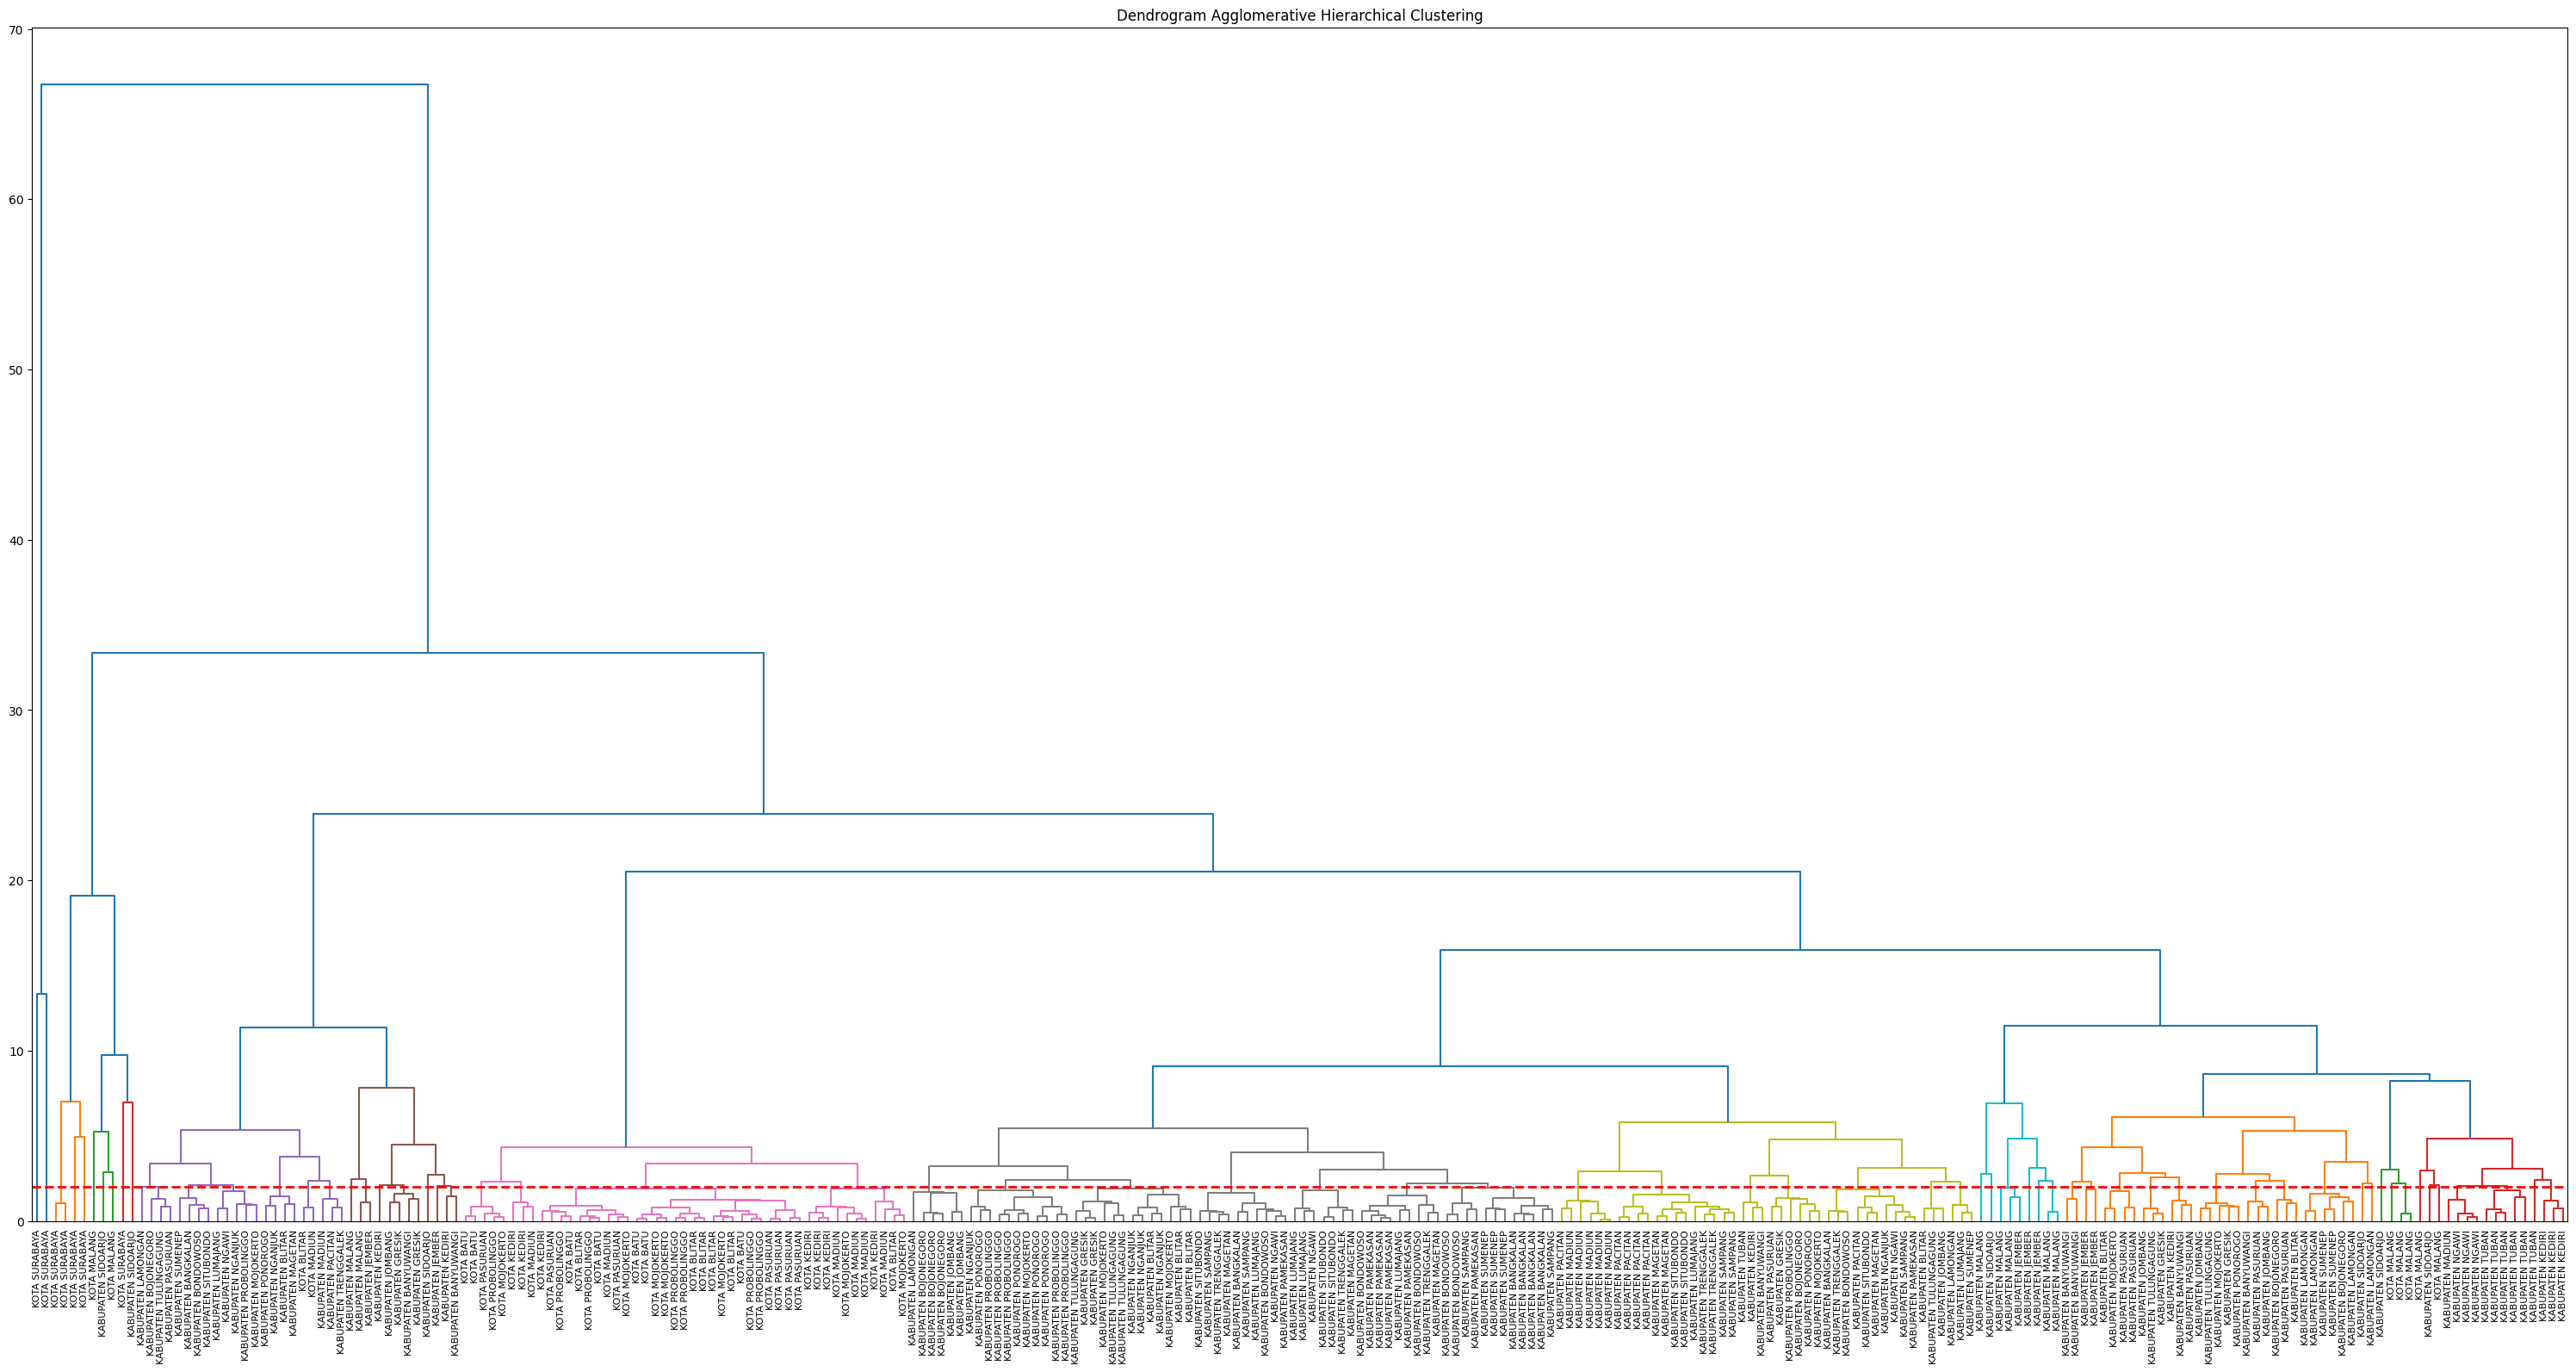

In [69]:

plt.figure(figsize=(38,18))

dendrogram(
    linkage_matrix,
    color_threshold=8,
    labels=df_robust_ahc["nama_kabupaten_kota"].values,
    leaf_rotation=90,
    leaf_font_size=8,
    show_leaf_counts=True,
)

plt.axhline(y=2, color="r", linestyle="--", linewidth=2)
plt.title("Dendrogram Agglomerative Hierarchical Clustering")

plt.show()

In [70]:
# ==========================================================
# 1. EVALUASI K SUB-CLUSTER
# ==========================================================

evaluasi_subcluster = []
k_optimal_subcluster = {}

max_k = 10

for cluster in sorted(df_hasil['cluster_ahc'].unique()):

    # Mengambil data berdasarkan cluster utama
    data_cluster = df_hasil.loc[
        df_hasil['cluster_ahc'] == cluster,
        kolom_numerik
    ]

    # K maksimal tidak boleh >= jumlah data
    max_k_cluster = min(max_k, len(data_cluster) - 1)

    for k in range(2, max_k_cluster + 1):

        ahc_sub = AgglomerativeClustering(
            n_clusters=k,
            linkage='ward'
        )

        labels_sub = ahc_sub.fit_predict(
            data_cluster
        )

        silhouette = silhouette_score(
            data_cluster,
            labels_sub
        )

        dbi = davies_bouldin_score(
            data_cluster,
            labels_sub
        )

        chi = calinski_harabasz_score(
            data_cluster,
            labels_sub
        )

        evaluasi_subcluster.append({
            'Cluster Utama': cluster,
            'Jumlah Sub Cluster (K)': k,
            'Silhouette Score': silhouette,
            'Davies-Bouldin Index': dbi,
            'Calinski-Harabasz Index': chi
        })


# ==========================================================
# 2. TABEL HASIL EVALUASI
# ==========================================================

evaluasi_subcluster_df = pd.DataFrame(
    evaluasi_subcluster
)

evaluasi_subcluster_df = (
    evaluasi_subcluster_df
    .sort_values([
        'Cluster Utama',
        'Jumlah Sub Cluster (K)'
    ])
    .reset_index(drop=True)
)

print("\n=== HASIL EVALUASI SUB-CLUSTER ===")
display(
    evaluasi_subcluster_df.round(4)
)


=== HASIL EVALUASI SUB-CLUSTER ===


,Cluster Utama,Jumlah Sub Cluster (K),Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,1,2,0.4652,0.7715,287.3179
1,1,3,0.5168,0.5979,498.3484
2,1,4,0.5455,0.5141,649.7359
3,1,5,0.5959,0.5437,992.6601
4,1,6,0.6000,0.5084,1034.8950
5,1,7,0.5483,0.5580,1042.2012
6,1,8,0.5543,0.6297,1054.1702
7,1,9,0.5008,0.6926,1122.9196
8,1,10,0.5065,0.7187,1179.0094


In [71]:
# --------------------------
# K OPTIMAL SUB-CLUSTER
# --------------------------

print("========== K OPTIMAL SUB-CLUSTER ==========")

hasil_cluster = evaluasi_subcluster_df[
    evaluasi_subcluster_df['Cluster Utama'] == 1
    ]

print(f"\n========== CLUSTER UTAMA ==========")

k_optimal_silhouette = hasil_cluster.loc[
        hasil_cluster['Silhouette Score'].idxmax(),
        'Jumlah Sub Cluster (K)'
    ]

print(
        "1. K Optimal berdasarkan Silhouette Score:",
        k_optimal_silhouette
    )


k_optimal_dbi = hasil_cluster.loc[
        hasil_cluster['Davies-Bouldin Index'].idxmin(),
        'Jumlah Sub Cluster (K)'
    ]

print(
        "2. K Optimal berdasarkan Davies-Bouldin Index:",
        k_optimal_dbi
    )


k_optimal_chi = hasil_cluster.loc[
        hasil_cluster['Calinski-Harabasz Index'].idxmax(),
        'Jumlah Sub Cluster (K)'
    ]

print(
        "3. K Optimal berdasarkan Calinski-Harabasz Index:",
        k_optimal_chi
    )

========== K OPTIMAL SUB-CLUSTER ==========

========== CLUSTER UTAMA ==========
1. K Optimal berdasarkan Silhouette Score: 6
2. K Optimal berdasarkan Davies-Bouldin Index: 6
3. K Optimal berdasarkan Calinski-Harabasz Index: 10


In [72]:
# ==========================================================
# 1. CLUSTERING SUB-CLUSTER
# ==========================================================

hasil_subcluster = []

for cluster in sorted(df_hasil['cluster_ahc'].unique()):

    # Ambil data berdasarkan cluster utama
    df_cluster = df_hasil[
        df_hasil['cluster_ahc'] == cluster
    ].copy()

    jumlah_data = len(df_cluster)

    # K sub-cluster
    k_sub = 6

    # Jika jumlah data kurang dari K,
    # sub-clustering tidak dapat dilakukan
    if jumlah_data < k_sub:

        print(
            f"Cluster Utama {cluster}: "
            f"{jumlah_data} data → tidak dilakukan sub-clustering"
        )

        df_cluster['sub_cluster'] = 1

        hasil_subcluster.append(df_cluster)

        continue

    # Mengambil data numerik
    X_sub = df_cluster[kolom_numerik]

    # Agglomerative sub-cluster
    kmeans_sub = AgglomerativeClustering(
        n_clusters=k_sub,
        linkage='ward',
        metric='euclidean'
    )

    sub_cluster = kmeans_sub.fit_predict(X_sub)

    # Label sub-cluster dimulai dari 1
    df_cluster['sub_cluster'] = sub_cluster + 1

    # Simpan hasil
    hasil_subcluster.append(df_cluster)


# ==========================================================
# 2. GABUNGKAN HASIL SUB-CLUSTER
# ==========================================================

hasil_subcluster = pd.concat(
    hasil_subcluster,
    ignore_index=True
)


# ==========================================================
# 3. JUMLAH ANGGOTA SUB-CLUSTER
# ==========================================================

jumlah_anggota_subcluster = (
    hasil_subcluster
    .groupby(
        [
            'cluster_ahc',
            'sub_cluster'
        ]
    )
    .size()
    .reset_index(
        name='Jumlah Anggota'
    )
    .sort_values(
        [
            'cluster_ahc',
            'sub_cluster'
        ]
    )
    .reset_index(drop=True)
)

print("========== JUMLAH ANGGOTA SUB-CLUSTER ==========")

display(jumlah_anggota_subcluster)


# ==========================================================
# 4. TABEL HASIL LABELING
# ==========================================================

df_hasil_sub = (
    hasil_subcluster
    .sort_values(
        [
            'cluster_ahc',
            'sub_cluster'
        ]
    )
    .reset_index(drop=True)
)

print("========== HASIL LABELING SUB-CLUSTER ==========")

display(df_hasil_sub)

Cluster Utama 2: 2 data → tidak dilakukan sub-clustering
========== JUMLAH ANGGOTA SUB-CLUSTER ==========


,cluster_ahc,sub_cluster,Jumlah Anggota
0,1,1,92
1,1,2,28
2,1,3,13
3,1,4,49
4,1,5,76
5,1,6,6
6,2,1,2


========== HASIL LABELING SUB-CLUSTER ==========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk,cluster_ahc,sub_cluster
0,35,JAWA TIMUR,3504,TULUNGAGUNG,2018,14,18,609,263,1098,114929,507,1109547,1,1
1,35,JAWA TIMUR,3505,BLITAR,2018,6,18,540,233,837,65232,392,1230159,1,1
2,35,JAWA TIMUR,3508,LUMAJANG,2018,3,22,416,105,990,64334,222,1124756,1,1
3,35,JAWA TIMUR,3513,PROBOLINGGO,2018,13,20,817,82,1053,45539,283,1124989,1,1
4,35,JAWA TIMUR,3516,MOJOKERTO,2018,10,17,636,136,1176,46130,473,1120249,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3507,MALANG,2023,0,39,1369,0,3698,830242,2007,2711102,1,6
262,35,JAWA TIMUR,3578,SURABAYA,2023,41,22,1891,0,10883,875411,5675,3009286,1,6
263,35,JAWA TIMUR,3578,SURABAYA,2024,40,23,69,0,7446,851331,2299,3018022,1,6
264,35,JAWA TIMUR,3578,SURABAYA,2021,41,22,1950,5299,9444,479,49775,2970952,2,1


In [73]:
#===============================================================================
# SIMPAN DATA
#===============================================================================
df_hasil_sub.to_csv('data_sub-cluster_ahc.csv', index=False)

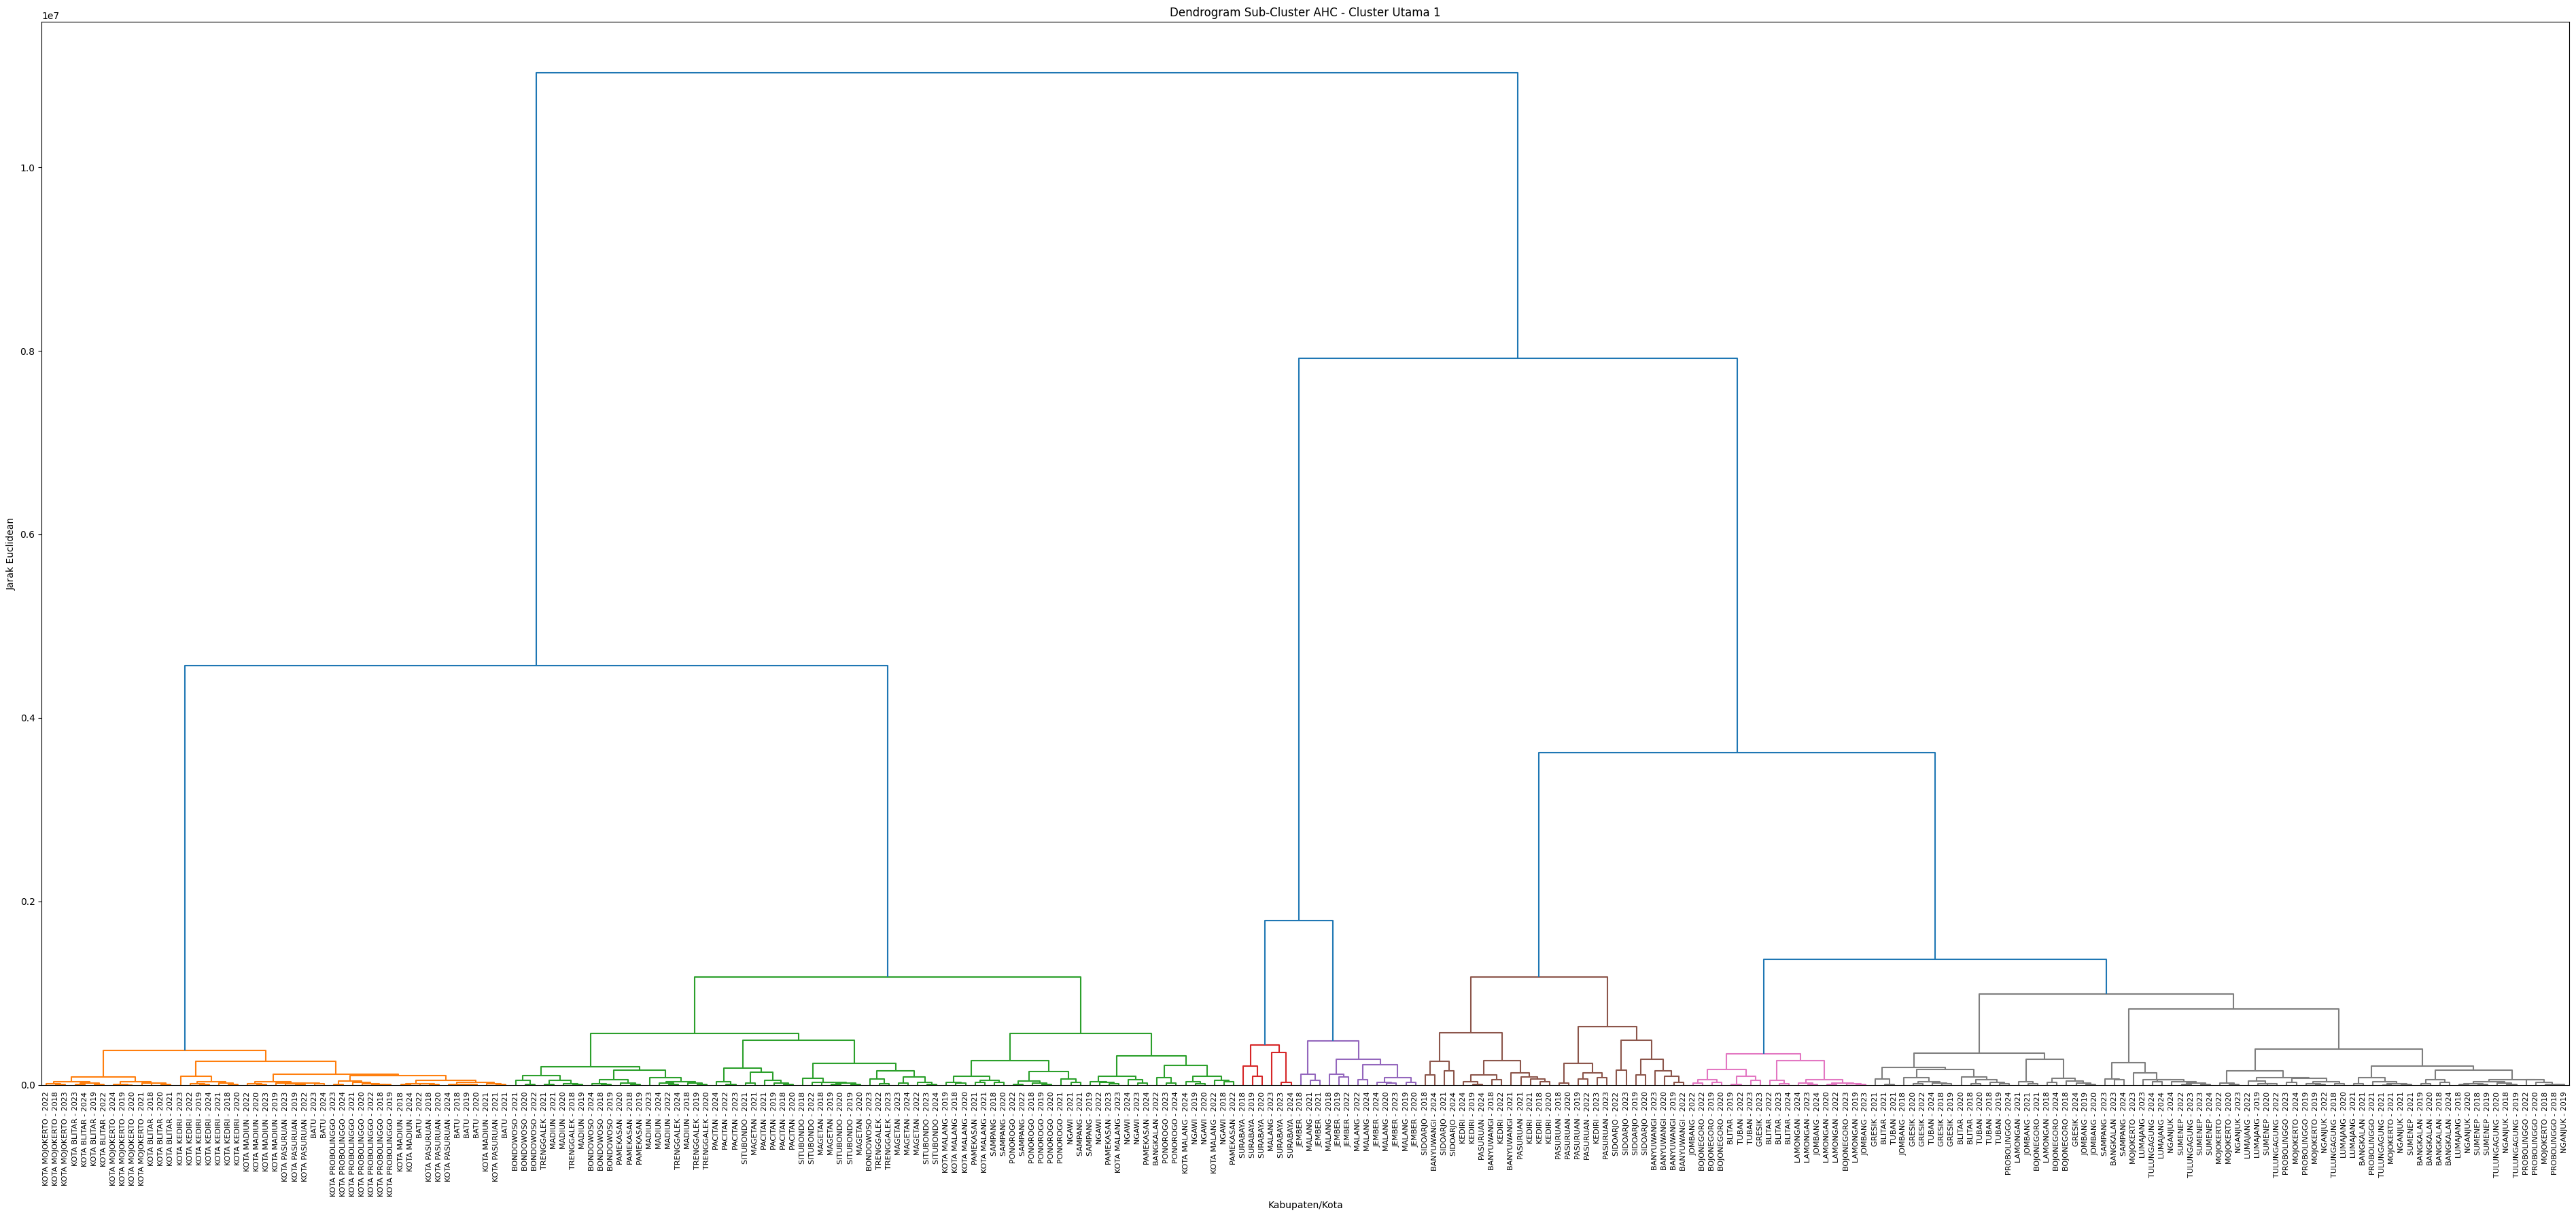

IndexError: index -6 is out of bounds for axis 0 with size 1

<Figure size 3800x1800 with 0 Axes>

In [85]:
# ==========================================================
# DENDROGRAM SUB-CLUSTER AHC
# ==========================================================

for cluster in sorted(df_hasil['cluster_ahc'].unique()):

    # Ambil data berdasarkan cluster utama
    df_cluster = df_hasil[
        df_hasil['cluster_ahc'] == cluster
    ].copy()

    # Data numerik
    X_sub = df_cluster[kolom_numerik]

    # Hierarchical clustering
    Z_sub = linkage(
        X_sub,
        method='ward',
        metric='euclidean'
    )

    # Plot dendrogram
    plt.figure(figsize=(38, 18))

    dendrogram(
        Z_sub,
       color_threshold = Z_sub[-6, 2],
        labels=(
    df_cluster["nama_kabupaten_kota"].astype(str)
    + " - "
    + df_cluster["tahun"].astype(str)
).values,
        leaf_rotation=90,
        leaf_font_size=8,
    
    )

    plt.title(
        f'Dendrogram Sub-Cluster AHC - Cluster Utama {cluster}'
    )

    plt.xlabel('Kabupaten/Kota')
    plt.ylabel('Jarak Euclidean')

    plt.tight_layout()
    plt.show()